# Maxwell speed distribution function
The distribution function for speed of particles in an ideal gas at temperature T is given by

$$
f(\nu) = 4\pi\left(\frac{m}{2\pi kT}\right)^{\frac{3}{2}} {\nu}^2 e^{\frac{-m{\nu}^2}{2kT}}
$$

Let $a = \frac{m}{2kT}$  
The function at a particular a becomes

$$
f(\nu) = 4\pi\left(\frac{a}{\pi}\right)^{\frac{3}{2}} {\nu}^2 e^{-a{\nu}^2}
$$

where  
$m$ is the mass of gas molecules  
$k$ is the Boltzmann constant  
$T$ is the absolute temperature  
$v$ represents the speed of gas molecules  

In [10]:
import sys
!{sys.executable} -m pip install -U "molmass[all]"

  Obtaining dependency information for molmass[all] from https://files.pythonhosted.org/packages/03/12/b6f548ac321f0239c3523b32bd629ccf8025ff59fbf8dbada22b0de96ce2/molmass-2026.1.8-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/73.8 kB ? eta -:--:--
   ---------------------------------------- 73.8/73.8 kB 2.1 MB/s eta 0:00:00


In [53]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from molmass import Formula, FormulaError  #for calculating molar mass
from scipy.constants import k  #boltzmann constant
from scipy.constants import Avogadro as Na  #Avogadro number
from adjustText import adjust_text

In [16]:
#input func for formula and mass
def input_mass():
    while(True):
        name = input("Enter the molecular formula of gas: ").strip()
        try:
            f = Formula(name)
            mass = f.mass
        except FormulaError:
            print('Invalid Input')
            continue
        else:
            break
    print(f'Molecular mass of {f} is {mass}')
    return name, mass

In [17]:
#inputs
V = np.linspace(0, 4000, 2000)  #speed in m/s
T = np.linspace(300, 900, 3)  #temperature in Kelvin
n = int(input('Enter number of gases: '))
gases = {}
for i in range(n):
    f, mass = input_mass()  #molecular weight in g/mol
    M = mass/(Na*1000)  #molecular weight in Kg
    gases[f] = M

Enter number of gases: 4
Enter the molecular formula of gas: o2
Invalid Input
Enter the molecular formula of gas: O2
Molecular mass of O2 is 31.99881
Enter the molecular formula of gas: N2
Molecular mass of N2 is 28.013406
Enter the molecular formula of gas: H2
Molecular mass of H2 is 2.015882
Enter the molecular formula of gas: Ne
Molecular mass of Ne is 20.1797


In [18]:
#maxwell speed distribution func
def f(vel, a):
    return 4*np.pi*((a/np.pi)**(3/2))*(vel**2)*np.exp(-a*vel**2)

In [19]:
#calculation of f(E), vmp, vavg, vrms
data = {}
for gas in gases.keys():
    data_g={}  #data for a particular gas
    for temp in T:
        #calculating f(E) at a particular temp for a gas G
        a = gases[gas]/(2*k*temp)
        points= []
        for v in V:
            points.append(f(v, a))
        
        #calculating vmp, vavg, vrms
        y = np.array(points)
        idx = np.argmax(y)
        vmp = V[idx]
        vrms = vmp*((3/2)**(1/2))
        vavg = vmp*2/((np.pi)**(1/2))
        
        #adding data 
        data_g[temp] = {'Points' : points,
                        'V_{mp}' : (vmp, points[idx]),    #(Most probable velocity, f(Most probable velocity))
                        'V_{avg}' : (vavg, f(vavg, a)),   #(Average velocity, f(Average velocity))
                        'V_{rms}' : (vrms, f(vrms, a))}   #(Root mean squared velocity, f(Root mean squared velocity))
    data[gas] = data_g

In [ ]:
data

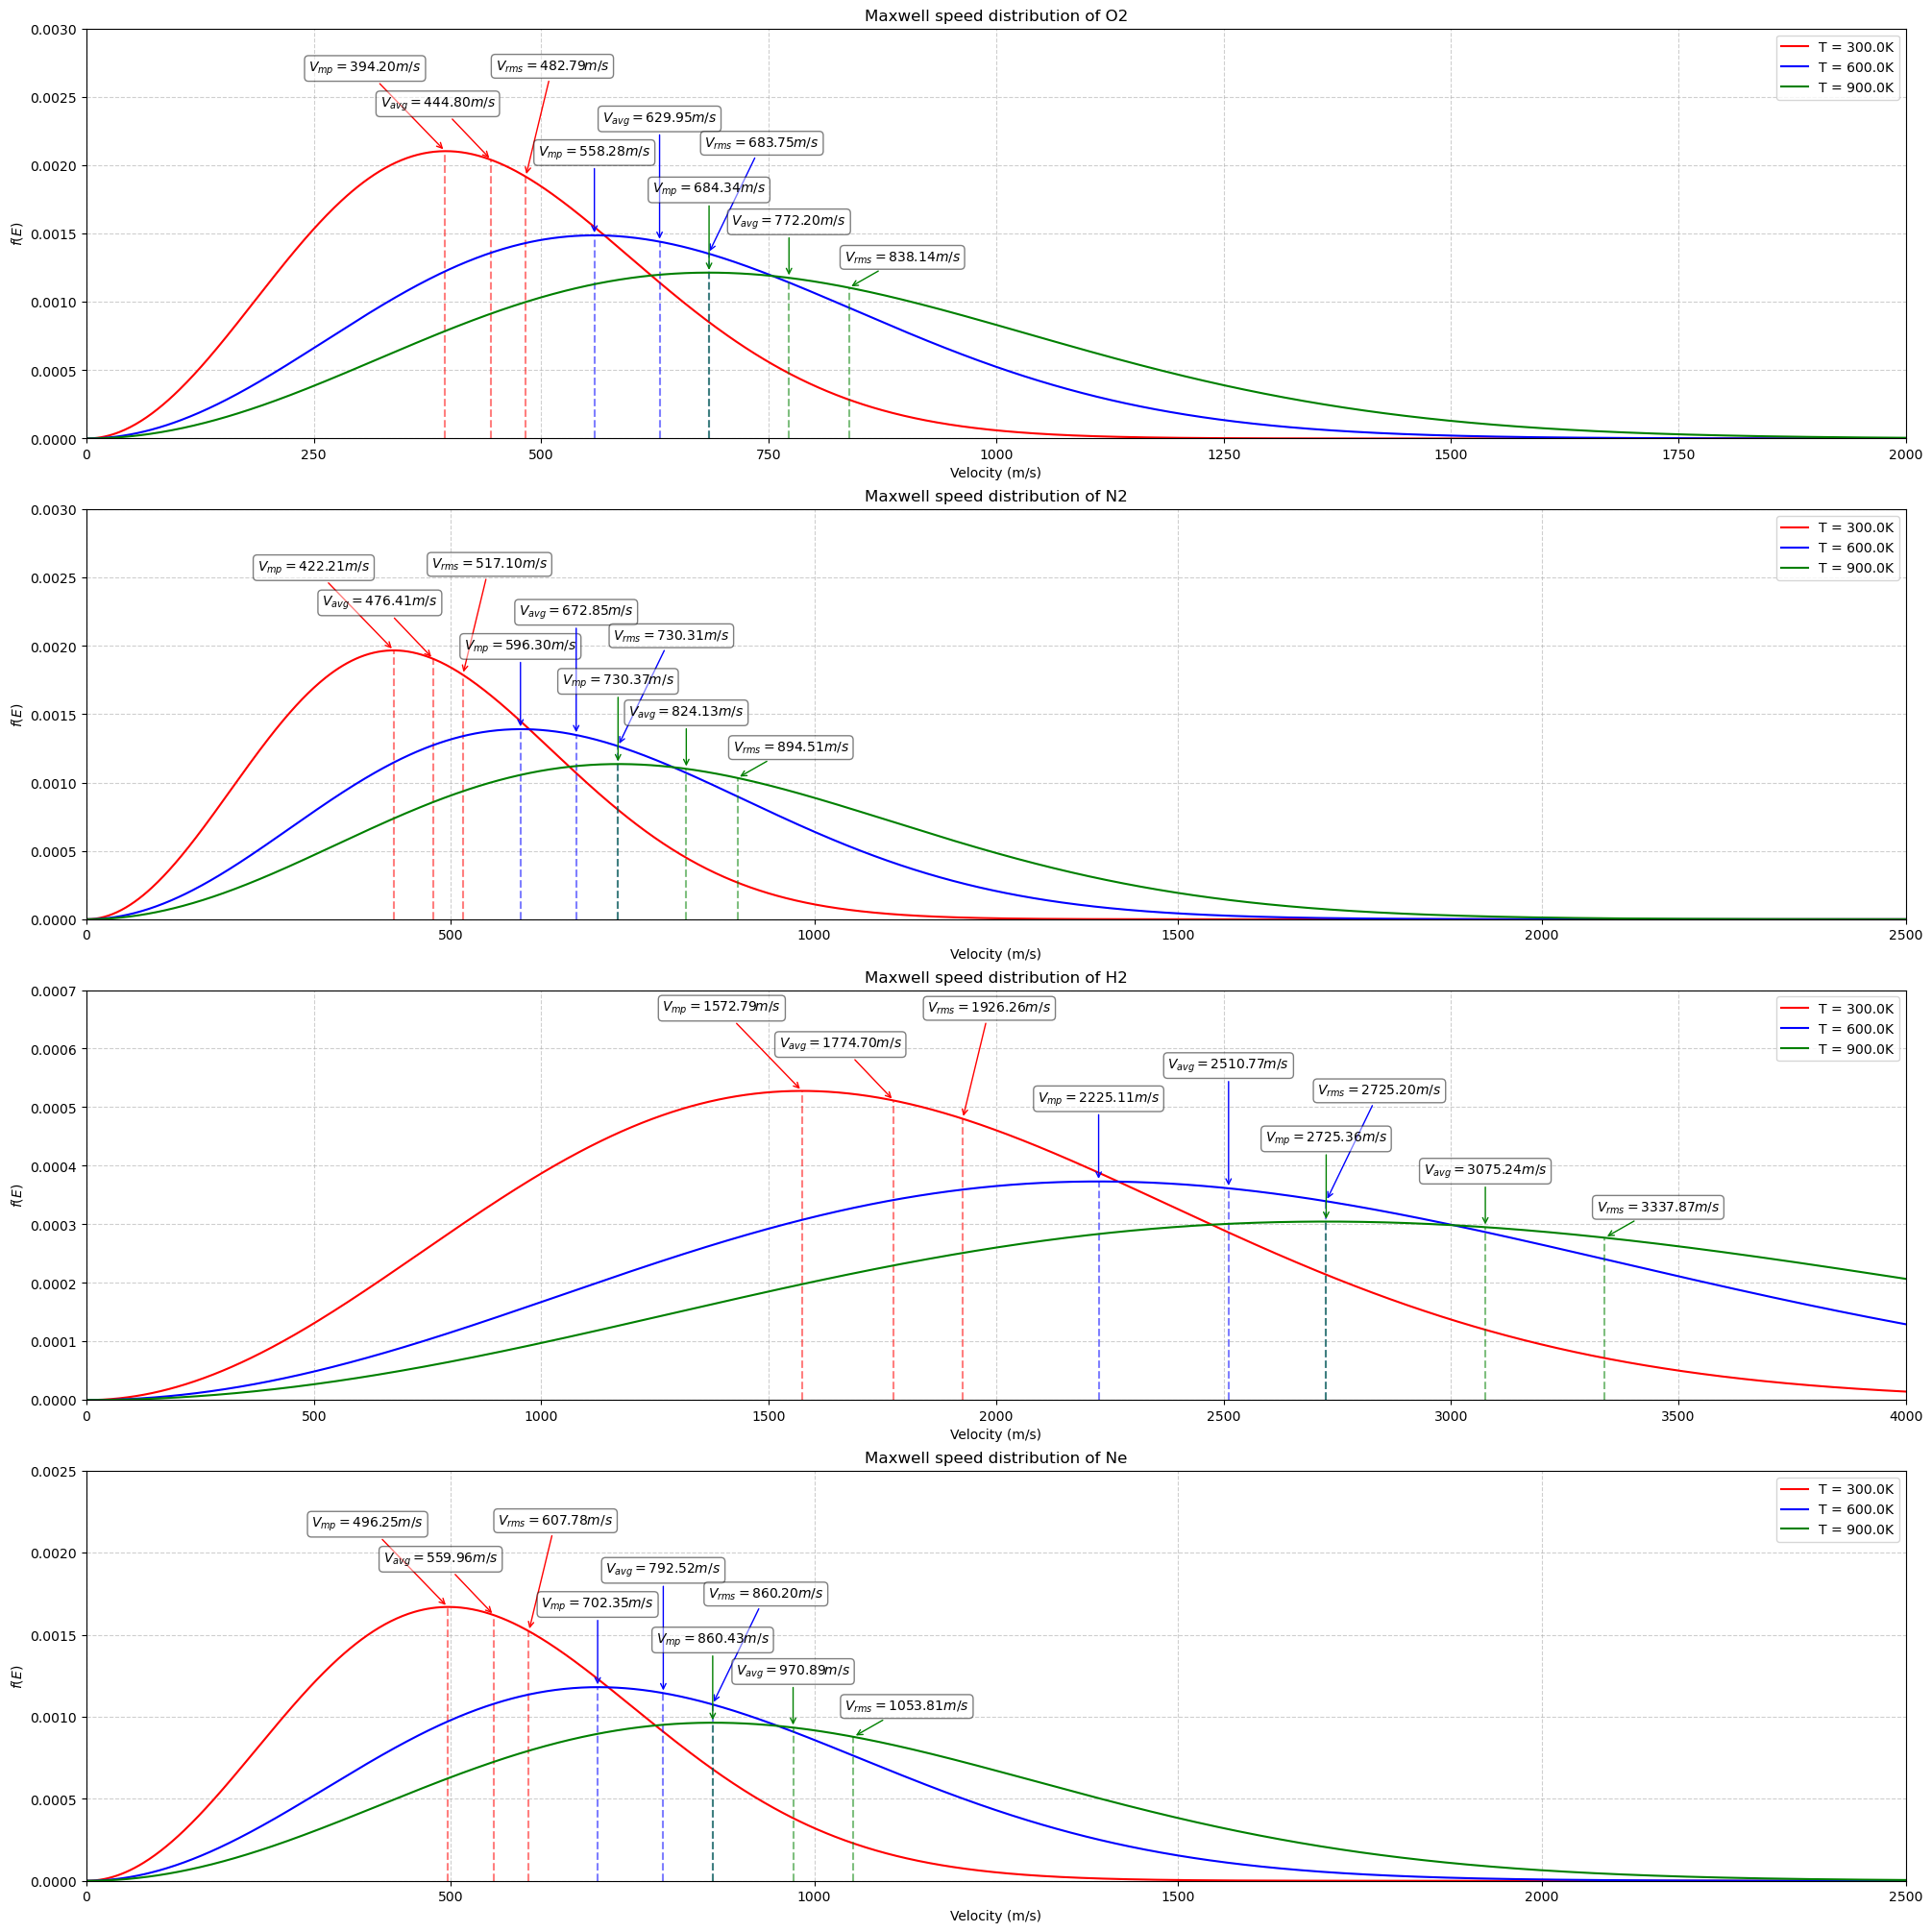

In [78]:
#plotting of f(E), vmp, vavg, vrms (annotaion using annonate())
fig, axes =plt.subplots(nrows=n, figsize=(20,20), constrained_layout=True)
axes = axes.flatten()  #converting into 1D for easy looping

colors = ['red', 'blue', 'green']
x_lim = [2000,2500, 4000, 2500]
y_lim = [0.003, 0.003, 0.0007, 0.0025]
offsets = [[(-60, 60), (-40, 40), (20, 80)],
          [(-0, 60), (0, 90), (40, 80)],
          [(-0, 60), (0, 40), (40, 20)]]

for i, d in enumerate(data):    #iterating over gases
    ax = axes[i]
    
    for j, temp in enumerate(T):    #iterating over temperatures
        k=0
        
        for key, val in data[d][temp].items():    #iterating over points, v_mp, v_rms, v_avg 
            
            if(key=='Points'):
                ax.plot(V, val, label=f'T = {temp}K', color=colors[j])     #for plotting graph
            else:                                                          #for projection, annotation of v_mp, v_rms, v_avg
                ax.vlines(val[0], 0, val[1], linestyles='dashed',
                          color=colors[j], alpha=0.5)

                dx, dy = offsets[j][k]
                
                ax.annotate(
                    rf'${key}={val[0]:.2f} m/s$',
                    xy=(val[0], val[1]), xycoords='data',    #actual point
                    xytext=(dx, dy), textcoords='offset points',    #offset
                    ha="center",
                    bbox=dict(boxstyle="round", fc="white", alpha=0.5),
                    arrowprops=dict(arrowstyle="->", color=colors[j])
                )
                k += 1
                
    #subplot editing
    ax.grid(True, linestyle='--', alpha=0.6)       # Enable grid
    ax.set_xlabel('Velocity (m/s)')               # Common X label
    ax.set_ylabel(r'$f(E)$')      # Common Y label
    ax.set_title(f'Maxwell speed distribution of {list(data.keys())[i]}')       #title
    ax.tick_params(axis='both', labelsize=10)      # Tick label size
    ax.set_xlim(0,x_lim[i])
    ax.set_ylim(0, y_lim[i])
    ax.legend()

plt.show()

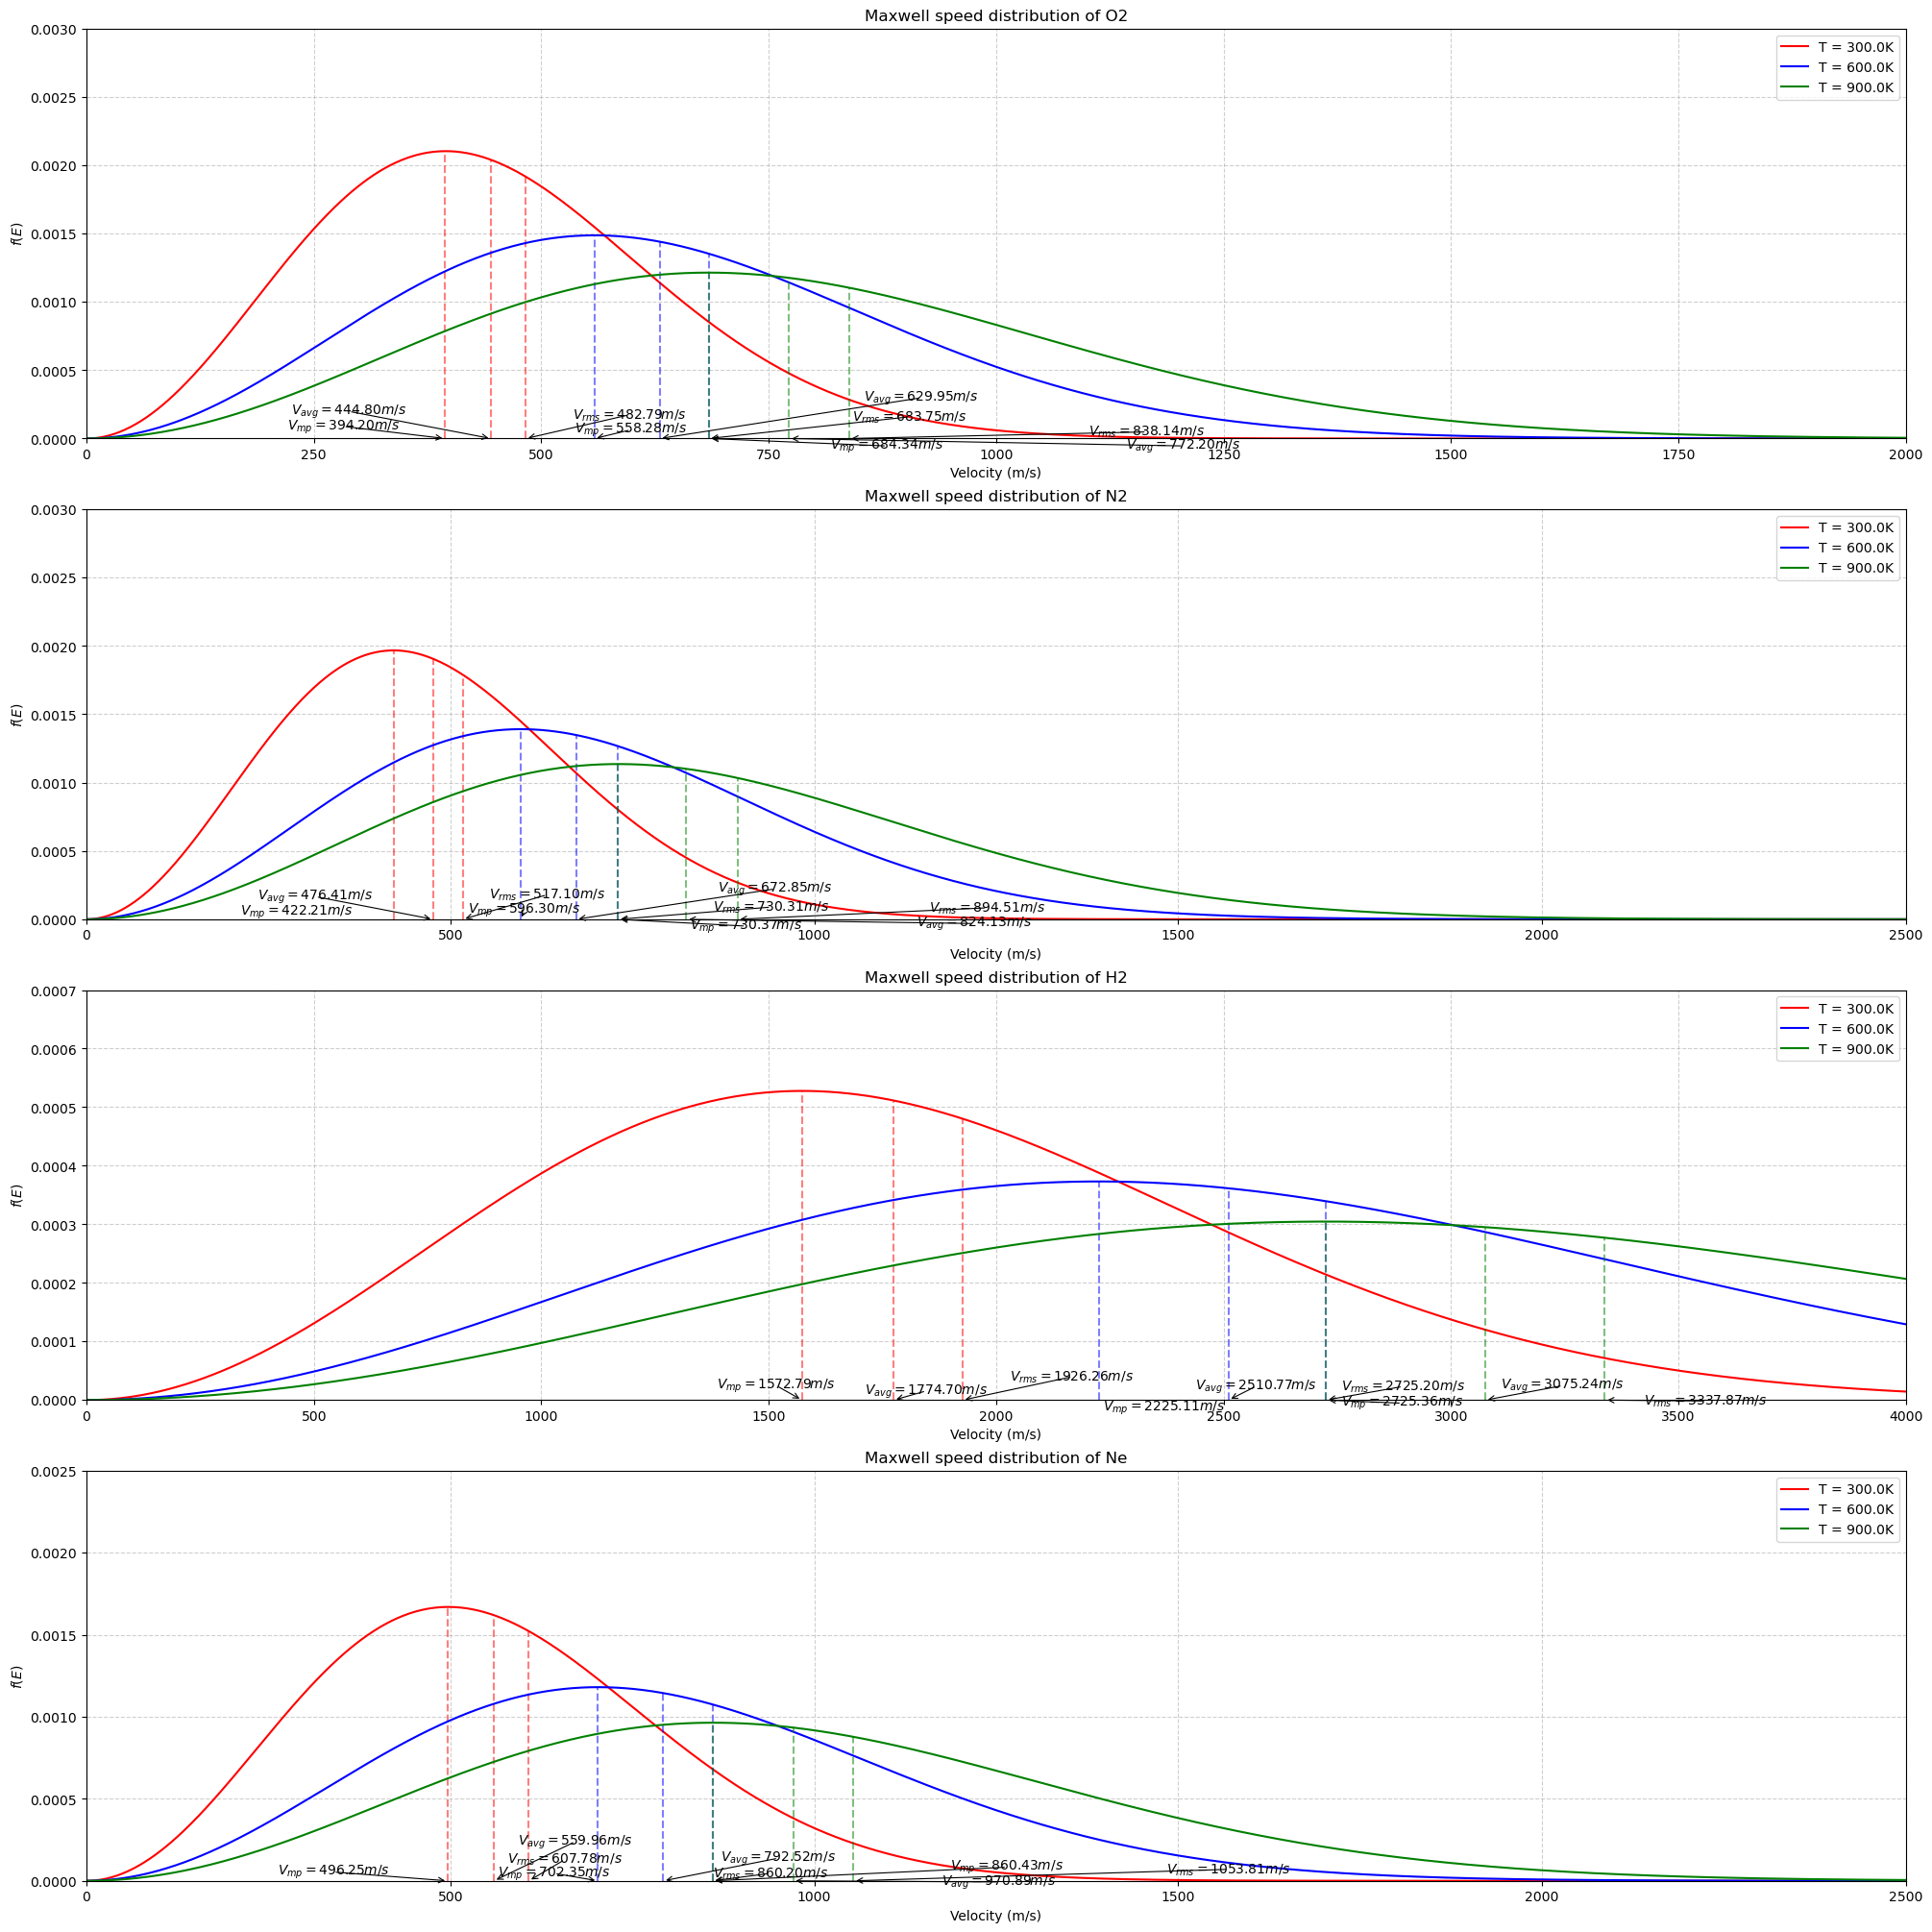

In [84]:
#plotting of f(E), vmp, vavg, vrms (annotaion using adjust_text)
fig, axes =plt.subplots(nrows=n, figsize=(20,20), constrained_layout=True)
axes = axes.flatten()  #converting into 1D for easy looping

colors = ['red', 'blue', 'green']
x_lim = [2000,2500, 4000, 2500]
y_lim = [0.003, 0.003, 0.0007, 0.0025]

for i, d in enumerate(data):    #iterating over gases
    ax = axes[i]
    texts=[]
    
    for j, temp in enumerate(T):    #iterating over temperatures
        k=0
        
        for key, val in data[d][temp].items():    #iterating over points, v_mp, v_rms, v_avg 
            
            if(key=='Points'):
                ax.plot(V, val, label=f'T = {temp}K', color=colors[j])     #for plotting graph
            else:                                                          #for projection, annotation of v_mp, v_rms, v_avg
                ax.vlines(val[0], 0, val[1], linestyles='dashed', color=colors[j], alpha=0.5)
                # create text (no arrow yet)
                txt = ax.text(val[0], 0, rf'${key}={val[0]:.2f} m/s$')
                texts.append(txt)
                
    adjust_text(
        texts,
        ax=ax,
        move_only={'text':'x', 'points':'y'},
        arrowprops=dict(arrowstyle="->", color='black', lw=0.8)
    )
    

                
    #subplot editing
    ax.grid(True, linestyle='--', alpha=0.6)       # Enable grid
    ax.set_xlabel('Velocity (m/s)')               # Common X label
    ax.set_ylabel(r'$f(E)$')      # Common Y label
    ax.set_title(f'Maxwell speed distribution of {list(data.keys())[i]}')       #title
    ax.tick_params(axis='both', labelsize=10)      # Tick label size
    ax.set_xlim(0,x_lim[i])
    ax.set_ylim(0, y_lim[i])
    ax.legend()

plt.show()